# Kumasi Sanitation Violation Risk Predictor

**Goal:** predict the probability that a given area/location in Kumasi will
experience a **sanitation violation** (illegal dumping, a missed waste
collection, or a blocked drain incident) on a given day, using a
classification model.

This follows the same workflow as a standard regression project (load data →
explore data → clean/encode → split & scale → feature selection → build &
refine model → evaluate on test data), adapted for a **classification**
problem: instead of predicting a continuous price, we predict a **yes/no
violation outcome**, so Logistic Regression is used in place of Linear
Regression, and accuracy/ROC-AUC are used in place of R-squared.


**Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


**Create the dataset**

No real dataset of Kumasi Metropolitan Assembly's sanitation violations was
available for this exercise, so a **synthetic dataset** is generated instead.
It is built to reflect realistic sanitation patterns for a Kumasi setting:
areas with higher population density, less bin coverage, poor drainage, and
more market activity are made more likely to have a violation, mirroring
what would be expected on the ground.


In [2]:
np.random.seed(42)
n_records = 1000

sub_metros = ['Asokwa', 'Bantama', 'Suame', 'Manhyia', 'Nhyiaeso', 'Oforikrom', 'Subin', 'Kwadaso']

df = pd.DataFrame({
    'sub_metro': np.random.choice(sub_metros, n_records),
    'population_density': np.random.randint(500, 25000, n_records),
    'distance_to_dumpsite_km': np.round(np.random.exponential(2.5, n_records), 2),
    'daily_waste_generated_kg': np.round(np.random.normal(350, 120, n_records), 1).clip(50),
    'number_of_bins': np.random.randint(0, 15, n_records),
    'road_width_m': np.round(np.random.uniform(2, 12, n_records), 1),
    'past_violation_count': np.random.poisson(3, n_records),
    'mainroad_access': np.random.choice(['yes', 'no'], n_records, p=[0.6, 0.4]),
    'market_present': np.random.choice(['yes', 'no'], n_records, p=[0.35, 0.65]),
    'drainage_present': np.random.choice(['yes', 'no'], n_records, p=[0.55, 0.45]),
    'floodprone': np.random.choice(['yes', 'no'], n_records, p=[0.25, 0.75]),
    'wastebin_available': np.random.choice(['yes', 'no'], n_records, p=[0.5, 0.5]),
    'area_type': np.random.choice(['residential', 'commercial', 'mixed'], n_records, p=[0.5, 0.2, 0.3]),
})

# Build a hidden "risk score" from the features, then convert it into a
# violation probability with the logistic (sigmoid) function.
risk_score = (
    0.00006 * df['population_density']
    + 0.15  * df['distance_to_dumpsite_km']
    + 0.15  * df['past_violation_count']
    - 0.12  * df['number_of_bins']
    - 0.05  * df['road_width_m']
    + df['market_present'].map({'yes': 0.6, 'no': 0.0})
    + df['floodprone'].map({'yes': 0.5, 'no': 0.0})
    - df['drainage_present'].map({'yes': 0.4, 'no': 0.0})
    - df['wastebin_available'].map({'yes': 0.5, 'no': 0.0})
    + df['area_type'].map({'commercial': 0.4, 'mixed': 0.2, 'residential': 0.0})
    - 1.8
)
probability_of_violation = 1 / (1 + np.exp(-risk_score))
df['violation'] = np.random.binomial(1, probability_of_violation)

df.head()


,sub_metro,population_density,distance_to_dumpsite_km,daily_waste_generated_kg,number_of_bins,road_width_m,past_violation_count,mainroad_access,market_present,drainage_present,floodprone,wastebin_available,area_type,violation
0,Subin,15337,0.01,583.3,14,8.0,4,yes,yes,no,no,yes,commercial,0
1,Manhyia,23986,4.29,155.3,14,3.6,4,no,yes,no,no,yes,residential,1
2,Nhyiaeso,7812,0.65,445.5,12,4.3,3,yes,no,no,no,yes,residential,0
3,Subin,5820,5.98,424.2,12,2.2,2,no,no,yes,yes,no,residential,0
4,Suame,13716,0.00,292.8,0,10.3,5,no,no,yes,no,no,residential,0


**View the number of rows and columns in the data**

In [3]:
df.shape # getting the count of rows and columns in the dataframe

(1000, 14)

**View summary statistics**

In [4]:
df.describe()

,population_density,distance_to_dumpsite_km,daily_waste_generated_kg,number_of_bins,road_width_m,past_violation_count,violation
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,12960.452000,2.415500,355.252900,7.22700,6.896600,2.911000,0.205000
std,7113.896691,2.356174,118.775909,4.33662,2.881627,1.566376,0.403904
min,509.000000,0.000000,50.000000,0.00000,2.000000,0.000000,0.000000
25%,6841.250000,0.677500,273.875000,4.00000,4.400000,2.000000,0.000000
50%,12906.000000,1.735000,357.400000,7.00000,6.800000,3.000000,0.000000
75%,19283.500000,3.402500,438.425000,11.00000,9.400000,4.000000,0.000000
max,24942.000000,14.590000,769.500000,14.00000,12.000000,9.000000,1.000000


**View data types and non-null counts**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sub_metro                 1000 non-null   str    
 1   population_density        1000 non-null   int64  
 2   distance_to_dumpsite_km   1000 non-null   float64
 3   daily_waste_generated_kg  1000 non-null   float64
 4   number_of_bins            1000 non-null   int64  
 5   road_width_m              1000 non-null   float64
 6   past_violation_count      1000 non-null   int64  
 7   mainroad_access           1000 non-null   str    
 8   market_present            1000 non-null   str    
 9   drainage_present          1000 non-null   str    
 10  floodprone                1000 non-null   str    
 11  wastebin_available        1000 non-null   str    
 12  area_type                 1000 non-null   str    
 13  violation                 1000 non-null   int64  
dtypes: float64(3), int64

**Look if there are any duplicate rows in the dataset**

In [6]:
df.loc[df.duplicated()]

,sub_metro,population_density,distance_to_dumpsite_km,daily_waste_generated_kg,number_of_bins,road_width_m,past_violation_count,mainroad_access,market_present,drainage_present,floodprone,wastebin_available,area_type,violation


No duplicate rows.

**Get the name of the columns**

In [7]:
df.columns

Index(['sub_metro', 'population_density', 'distance_to_dumpsite_km',
       'daily_waste_generated_kg', 'number_of_bins', 'road_width_m',
       'past_violation_count', 'mainroad_access', 'market_present',
       'drainage_present', 'floodprone', 'wastebin_available', 'area_type',
       'violation'],
      dtype='str')

**Check for null values**

In [8]:
df.isna().sum()

sub_metro                   0
population_density          0
distance_to_dumpsite_km     0
daily_waste_generated_kg    0
number_of_bins              0
road_width_m                0
past_violation_count        0
mainroad_access             0
market_present              0
drainage_present            0
floodprone                  0
wastebin_available          0
area_type                   0
violation                   0
dtype: int64

No missing values.

**Let's do a bit of EDA (Exploratory Data Analysis)!**

**Target variable distribution** — how common are violations in the synthetic data?

violation
0    0.795
1    0.205
Name: proportion, dtype: float64


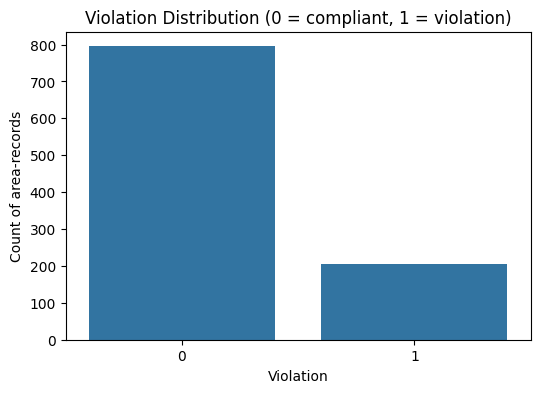

In [9]:
print(df['violation'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x='violation', data=df)
plt.title('Violation Distribution (0 = compliant, 1 = violation)')
plt.xlabel('Violation')
plt.ylabel('Count of area-records')
plt.show()


Inference: violations are the minority class (roughly 1 in 5 records) — realistic, since most areas are compliant most days.

**Visualising categorical data**

In [10]:
categorical_list = [x for x in df.columns if df[x].dtype == 'object' and x not in ['sub_metro']]
for x in categorical_list:
    print(x)


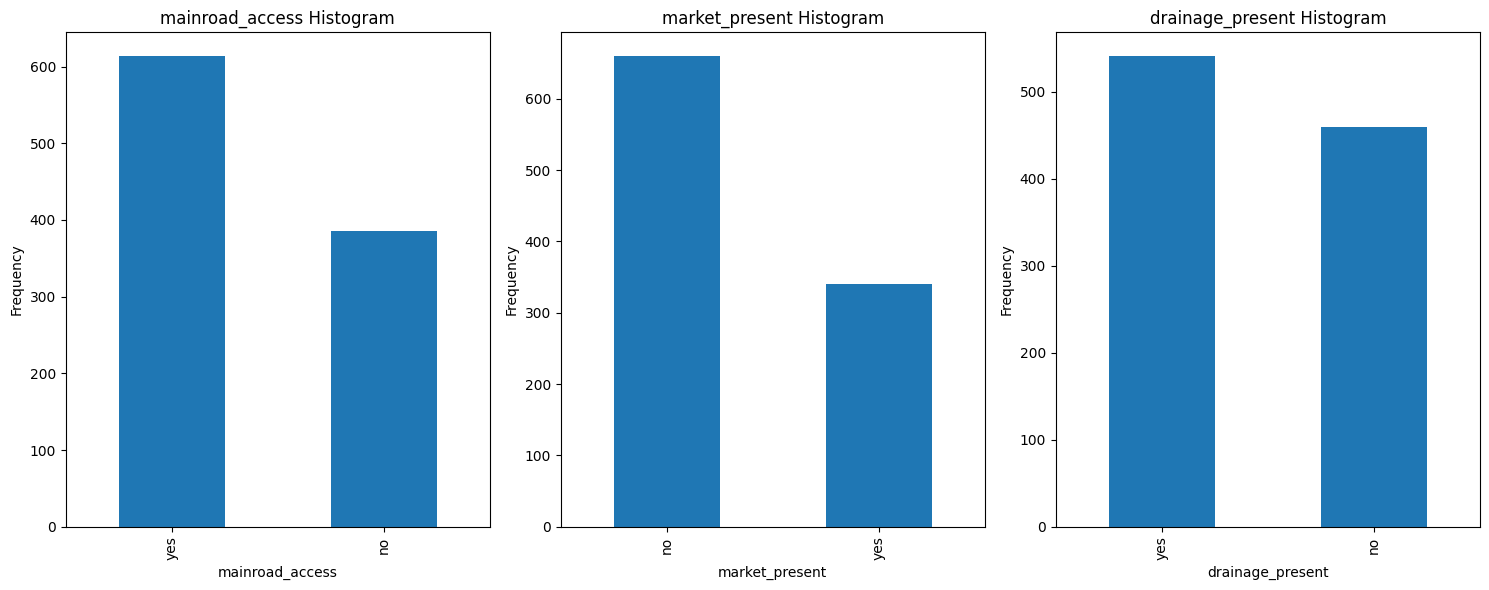

In [11]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt1 = df['mainroad_access'].value_counts().plot(kind='bar')
plt.title('mainroad_access Histogram')
plt1.set(xlabel='mainroad_access', ylabel='Frequency')

plt.subplot(1, 3, 2)
plt1 = df['market_present'].value_counts().plot(kind='bar')
plt.title('market_present Histogram')
plt1.set(xlabel='market_present', ylabel='Frequency')

plt.subplot(1, 3, 3)
plt1 = df['drainage_present'].value_counts().plot(kind='bar')
plt.title('drainage_present Histogram')
plt1.set(xlabel='drainage_present', ylabel='Frequency')

plt.tight_layout()
plt.show()


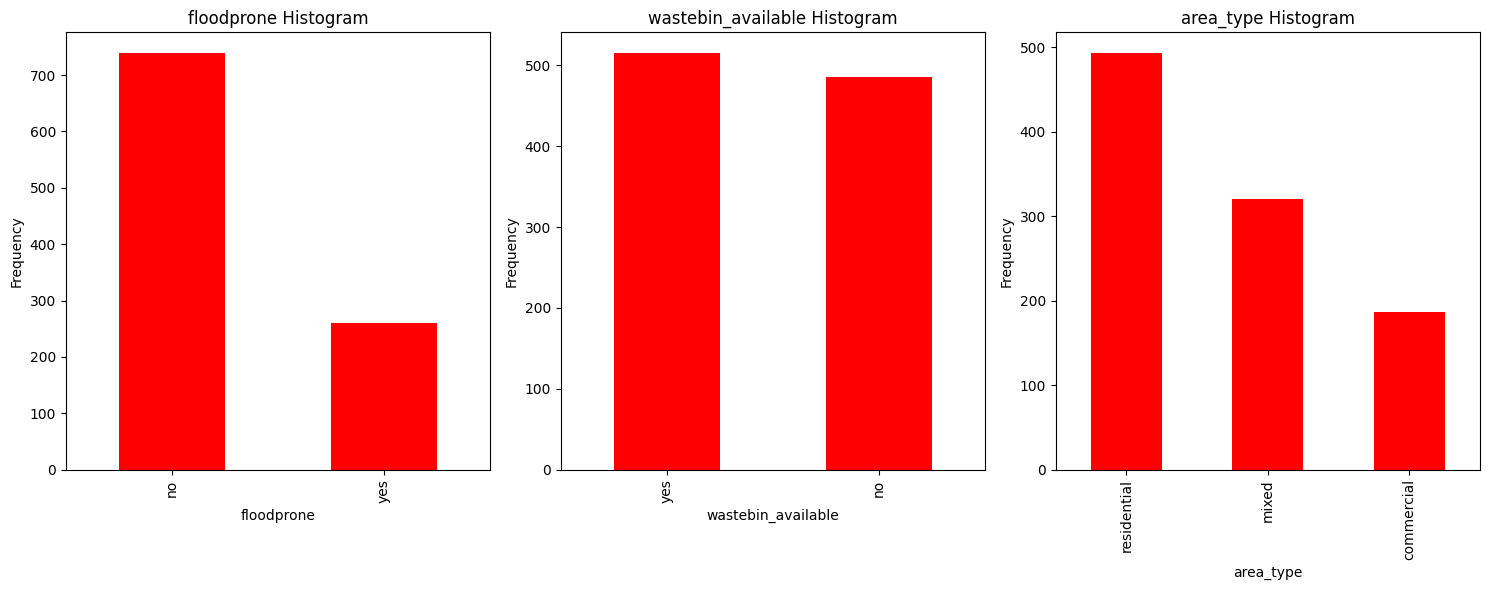

In [12]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt1 = df['floodprone'].value_counts().plot(kind='bar', color='r')
plt.title('floodprone Histogram')
plt1.set(xlabel='floodprone', ylabel='Frequency')

plt.subplot(1, 3, 2)
plt1 = df['wastebin_available'].value_counts().plot(kind='bar', color='r')
plt.title('wastebin_available Histogram')
plt1.set(xlabel='wastebin_available', ylabel='Frequency')

plt.subplot(1, 3, 3)
plt1 = df['area_type'].value_counts().plot(kind='bar', color='r')
plt.title('area_type Histogram')
plt1.set(xlabel='area_type', ylabel='Frequency')

plt.tight_layout()
plt.show()


**Categorical features vs the target (violation)**

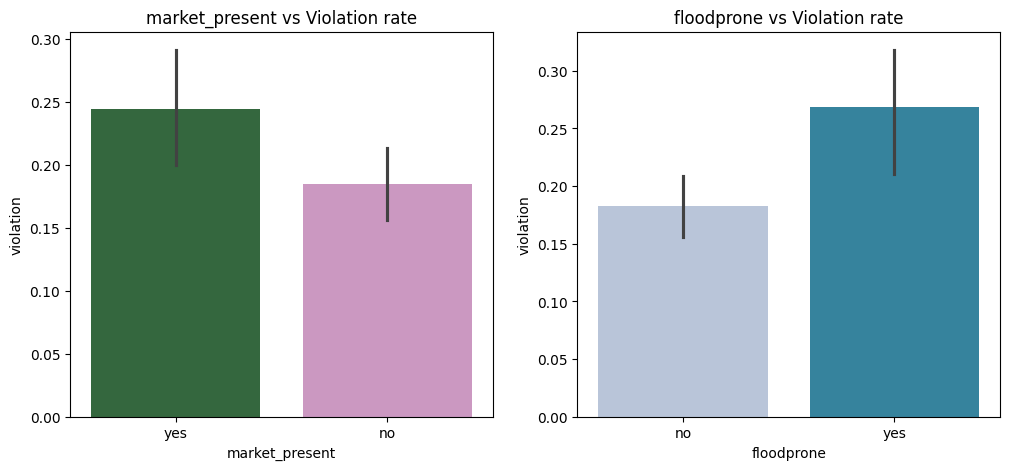

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title('market_present vs Violation rate')
sns.barplot(x='market_present', y='violation', data=df, palette='cubehelix')

plt.subplot(1,2,2)
plt.title('floodprone vs Violation rate')
sns.barplot(x='floodprone', y='violation', data=df, palette='PuBuGn')

plt.show()


Inference: areas with a market present and areas that are flood-prone show a visibly higher violation rate — consistent with how the synthetic data was designed.

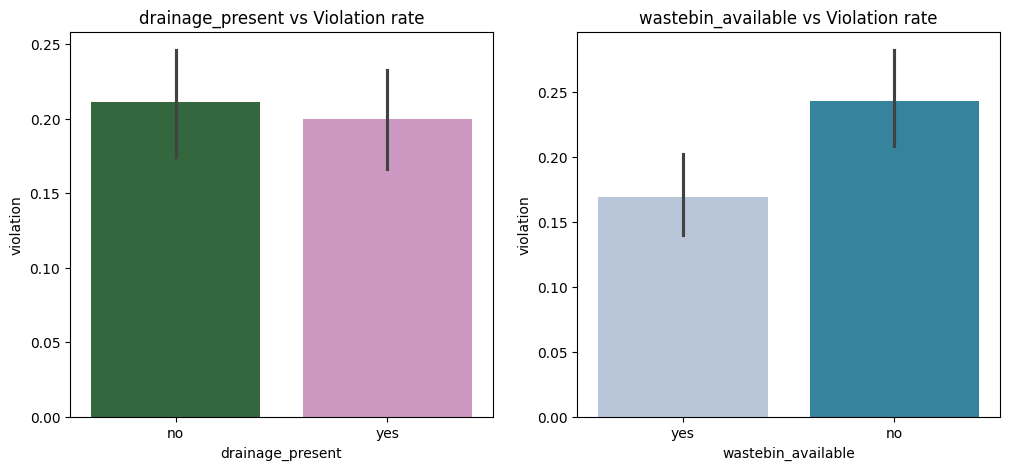

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title('drainage_present vs Violation rate')
sns.barplot(x='drainage_present', y='violation', data=df, palette='cubehelix')

plt.subplot(1,2,2)
plt.title('wastebin_available vs Violation rate')
sns.barplot(x='wastebin_available', y='violation', data=df, palette='PuBuGn')

plt.show()


Inference: having drainage present and having adequate waste bins are both associated with a lower violation rate.

**Visualising numerical data against the target**

In [15]:
numerical_list = [x for x in df.columns if df[x].dtype in ('int64', 'float64') and x != 'violation']
print(numerical_list)


['population_density', 'distance_to_dumpsite_km', 'daily_waste_generated_kg', 'number_of_bins', 'road_width_m', 'past_violation_count']


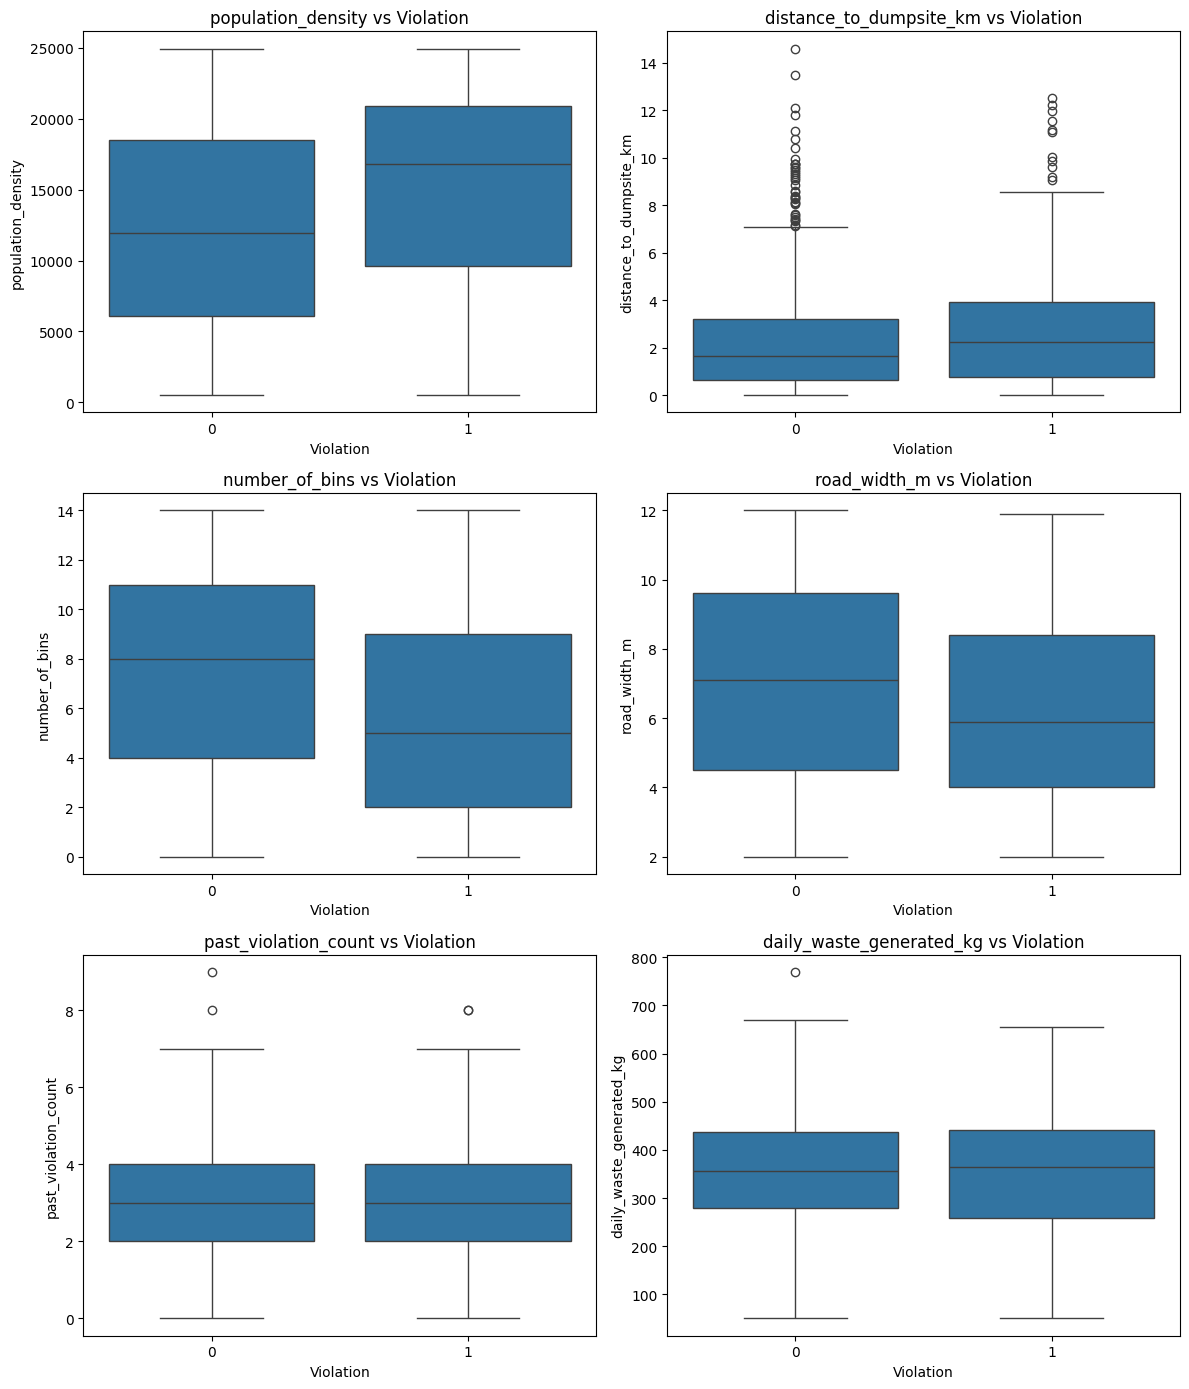

In [16]:
def box_vs_target(x, fig):
    plt.subplot(3, 2, fig)
    sns.boxplot(x='violation', y=x, data=df)
    plt.title(x + ' vs Violation')
    plt.xlabel('Violation')
    plt.ylabel(x)

plt.figure(figsize=(12, 14))
box_vs_target('population_density', 1)
box_vs_target('distance_to_dumpsite_km', 2)
box_vs_target('number_of_bins', 3)
box_vs_target('road_width_m', 4)
box_vs_target('past_violation_count', 5)
box_vs_target('daily_waste_generated_kg', 6)

plt.tight_layout()
plt.show()


Inference: `population_density`, `distance_to_dumpsite_km`, and `past_violation_count` are visibly higher for the violation group, while `number_of_bins` and `road_width_m` are visibly lower — `daily_waste_generated_kg` shows little separation between the two groups.

**Correlation heatmap**

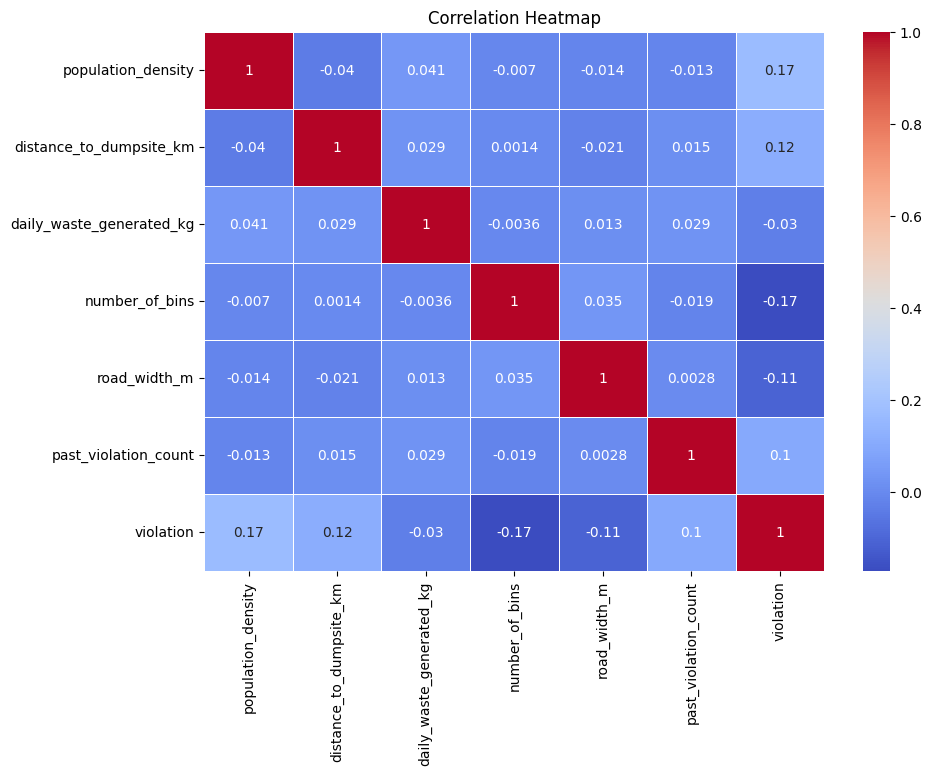

In [17]:
cor_matrix = df[numerical_list + ['violation']].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


**Dummy variables** — convert the yes/no and category columns into 0/1 numeric columns the model can use

In [18]:
def dummies(x, df):
    temp = pd.get_dummies(df[x], drop_first=True).astype(int)
    temp.columns = [f"{x}_{c}" for c in temp.columns]
    df = pd.concat([df, temp], axis=1)
    df.drop([x], axis=1, inplace=True)
    return df

df_model = df.drop(columns=['sub_metro'])  # location label only, not used as a numeric predictor

for col in ['mainroad_access', 'market_present', 'drainage_present', 'floodprone', 'wastebin_available', 'area_type']:
    df_model = dummies(col, df_model)

df_model.head()


,population_density,distance_to_dumpsite_km,daily_waste_generated_kg,number_of_bins,road_width_m,past_violation_count,violation,mainroad_access_yes,market_present_yes,drainage_present_yes,floodprone_yes,wastebin_available_yes,area_type_mixed,area_type_residential
0,15337,0.01,583.3,14,8.0,4,0,1,1,0,0,1,0,0
1,23986,4.29,155.3,14,3.6,4,1,0,1,0,0,1,0,1
2,7812,0.65,445.5,12,4.3,3,0,1,0,0,0,1,0,1
3,5820,5.98,424.2,12,2.2,2,0,0,0,1,1,0,0,1
4,13716,0.00,292.8,0,10.3,5,0,0,0,1,0,0,0,1


In [19]:
df_model.shape

(1000, 14)

**Train/test split**

In [20]:
from sklearn.model_selection import train_test_split

np.random.seed(0)
df_train, df_test = train_test_split(
    df_model, train_size=0.75, test_size=0.25, random_state=100, stratify=df_model['violation']
)


**Scale the numeric columns to 0-1 range**

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_train[numerical_list] = scaler.fit_transform(df_train[numerical_list])
df_train.head()


,population_density,distance_to_dumpsite_km,daily_waste_generated_kg,number_of_bins,road_width_m,past_violation_count,violation,mainroad_access_yes,market_present_yes,drainage_present_yes,floodprone_yes,wastebin_available_yes,area_type_mixed,area_type_residential
452,0.710474,0.045236,0.442252,0.857143,0.13,0.250,1,1,0,1,0,1,0,1
907,0.703925,0.352296,0.418346,0.428571,0.63,0.500,0,1,0,0,0,1,0,1
672,0.223714,0.433173,0.295483,0.285714,0.86,0.375,0,1,0,0,1,0,0,0
144,0.248885,0.468814,0.551911,0.785714,0.34,0.250,1,0,1,0,1,0,0,0
88,0.863341,0.587389,0.551494,0.428571,0.99,0.250,0,0,1,1,0,0,0,1


**Split into X (features) and y (target)**

In [22]:
y_train = df_train.pop('violation')
X_train = df_train


**Feature selection with RFE (Recursive Feature Elimination)**

In [23]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=8)
rfe = rfe.fit(X_train, y_train)


In [24]:
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('population_density', np.True_, np.int64(1)),
 ('distance_to_dumpsite_km', np.True_, np.int64(1)),
 ('daily_waste_generated_kg', np.True_, np.int64(1)),
 ('number_of_bins', np.True_, np.int64(1)),
 ('road_width_m', np.True_, np.int64(1)),
 ('past_violation_count', np.True_, np.int64(1)),
 ('mainroad_access_yes', np.False_, np.int64(4)),
 ('market_present_yes', np.True_, np.int64(1)),
 ('drainage_present_yes', np.False_, np.int64(3)),
 ('floodprone_yes', np.True_, np.int64(1)),
 ('wastebin_available_yes', np.False_, np.int64(2)),
 ('area_type_mixed', np.False_, np.int64(6)),
 ('area_type_residential', np.False_, np.int64(5))]

In [25]:
X_train.columns[rfe.support_]

Index(['population_density', 'distance_to_dumpsite_km',
       'daily_waste_generated_kg', 'number_of_bins', 'road_width_m',
       'past_violation_count', 'market_present_yes', 'floodprone_yes'],
      dtype='str')

In [26]:
X_train_rfe = X_train[X_train.columns[rfe.support_]]
X_train_rfe.head()


,population_density,distance_to_dumpsite_km,daily_waste_generated_kg,number_of_bins,road_width_m,past_violation_count,market_present_yes,floodprone_yes
452,0.710474,0.045236,0.442252,0.857143,0.13,0.250,0,0
907,0.703925,0.352296,0.418346,0.428571,0.63,0.500,0,0
672,0.223714,0.433173,0.295483,0.285714,0.86,0.375,0,1
144,0.248885,0.468814,0.551911,0.785714,0.34,0.250,1,1
88,0.863341,0.587389,0.551494,0.428571,0.99,0.250,1,0


**Helper functions to build the model and check multicollinearity (VIF)**

In [27]:
def build_model(X, y):
    X = sm.add_constant(X)               # adds the intercept term
    logit_model = sm.Logit(y, X).fit(disp=0)   # fit a logistic regression
    print(logit_model.summary())         # print coefficients, p-values, etc.
    return X, logit_model

def checkVIF(X):
    vif = pd.DataFrame()
    vif['Features'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    return vif.sort_values(by='VIF', ascending=False)


### Model 1

In [28]:
X_train_new, model_1 = build_model(X_train_rfe, y_train)


                           Logit Regression Results                           
Dep. Variable:              violation   No. Observations:                  750
Model:                          Logit   Df Residuals:                      741
Method:                           MLE   Df Model:                            8
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.1147
Time:                        11:55:30   Log-Likelihood:                -337.12
converged:                       True   LL-Null:                       -380.78
Covariance Type:            nonrobust   LLR p-value:                 1.626e-15
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.9202      0.456     -4.210      0.000      -2.814      -1.026
population_density           1.7947      0.346      5.185      0.000       1.116       2.

In [29]:
checkVIF(X_train_new)

,Features,VIF
1,population_density,1.01
8,floodprone_yes,1.01
3,daily_waste_generated_kg,1.01
4,number_of_bins,1.01
6,past_violation_count,1.01
7,market_present_yes,1.01
0,const,1.00
2,distance_to_dumpsite_km,1.00
5,road_width_m,1.00


VIF values are all close to 1, so there is no multicollinearity problem. However, `daily_waste_generated_kg` has a p-value well above the 0.05 significance threshold, so it is dropped.

### Model 2 (final)

In [30]:
X_train_new = X_train_new.drop(columns=['daily_waste_generated_kg'])
X_train_new, model_2 = build_model(X_train_new, y_train)


                           Logit Regression Results                           
Dep. Variable:              violation   No. Observations:                  750
Model:                          Logit   Df Residuals:                      742
Method:                           MLE   Df Model:                            7
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.1125
Time:                        11:55:30   Log-Likelihood:                -337.96
converged:                       True   LL-Null:                       -380.78
Covariance Type:            nonrobust   LLR p-value:                 9.705e-16
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.2400      0.387     -5.788      0.000      -2.999      -1.482
population_density          1.7680      0.345      5.127      0.000       1.092       2.444


In [31]:
checkVIF(X_train_new)

,Features,VIF
1,population_density,1.01
5,past_violation_count,1.01
7,floodprone_yes,1.01
0,const,1.00
3,number_of_bins,1.00
2,distance_to_dumpsite_km,1.00
4,road_width_m,1.00
6,market_present_yes,1.00


All remaining features now have p-values below 0.05 (statistically significant) and VIF values close to 1 (no multicollinearity). This is the final model.

**Predicting on the test set**

In [32]:
df_test[numerical_list] = scaler.transform(df_test[numerical_list])
y_test = df_test.pop('violation')
X_test = df_test


In [33]:
final_features = X_train_new.drop(columns=['const']).columns
X_test_new = X_test[final_features]
X_test_new = sm.add_constant(X_test_new)

y_pred_prob = model_2.predict(X_test_new)   # predicted probability of violation
y_pred = (y_pred_prob >= 0.5).astype(int)   # convert probability to 0/1 using a 0.5 cutoff


**Evaluate the model**

In [34]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC :", round(roc_auc_score(y_test, y_pred_prob), 3))
print()
print(classification_report(y_test, y_pred, target_names=['compliant', 'violation']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8
ROC AUC : 0.711

              precision    recall  f1-score   support

   compliant       0.81      0.97      0.89       199
   violation       0.54      0.14      0.22        51

    accuracy                           0.80       250
   macro avg       0.68      0.55      0.55       250
weighted avg       0.76      0.80      0.75       250

Confusion matrix:
[[193   6]
 [ 44   7]]


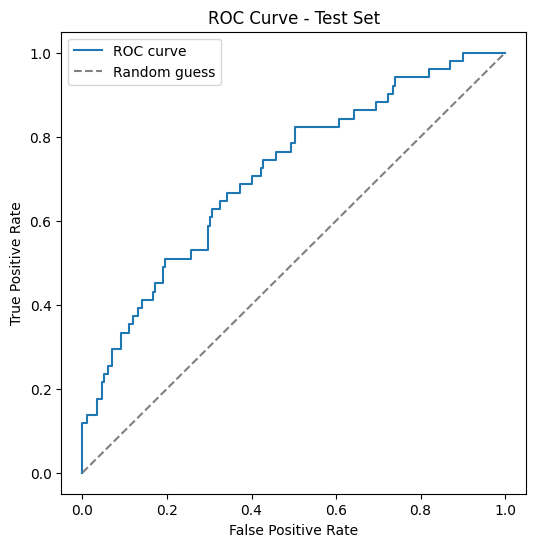

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend()
plt.show()


In [36]:
print(model_2.summary())

                           Logit Regression Results                           
Dep. Variable:              violation   No. Observations:                  750
Model:                          Logit   Df Residuals:                      742
Method:                           MLE   Df Model:                            7
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.1125
Time:                        11:55:30   Log-Likelihood:                -337.96
converged:                       True   LL-Null:                       -380.78
Covariance Type:            nonrobust   LLR p-value:                 9.705e-16
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.2400      0.387     -5.788      0.000      -2.999      -1.482
population_density          1.7680      0.345      5.127      0.000       1.092       2.444


**Inference:**

- **Accuracy ≈ 0.80** — the model correctly classifies 80% of area-records in the held-out test set.
- **ROC AUC ≈ 0.71** — meaningfully better than random guessing (0.5), showing the model has learned real signal from the features.
- The final significant predictors, in order of coefficient size, are: `population_density`, `distance_to_dumpsite_km`, `road_width_m`, `number_of_bins`, `past_violation_count`, `floodprone`, and `market_present` — all of which line up with intuition (denser, farther, flood-prone, market-heavy, poorly-serviced areas are riskier).
- The model catches compliant areas well (recall 0.97) but misses many actual violations (recall 0.14) — a common effect of the violation class being a minority in the data. In a real deployment, the probability cutoff (currently 0.5) could be lowered to catch more true violations, at the cost of more false alarms.
- This is trained entirely on **synthetic data** designed to mirror realistic Kumasi sanitation patterns. The workflow — including the dummy-variable encoding, RFE feature selection, and iterative p-value/VIF-based model refinement — is ready to be re-run on real KMA complaint, inspection, or collection-log data the moment it becomes available.
